In this work we will train different neural network models for extracting text and categorical features to predict salaries of Belarus vacancies from rabota.by, downloaded in notebook `downloading_data.ipynb`.

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [24]:
data = pd.read_csv('../data/clean_vacancies.csv', index_col=0)
data.shape

(22287, 19)

In [25]:
data.head()

,id,billing_type,name,response_letter_required,area,salary,allow_messages,experience,schedule,employment,description,accept_handicapped,accept_kids,driver_license_types,accept_incomplete_resumes,employer,has_test,accept_temporary,log1p_salary
1,94218916,Стандарт,Старший контролер-кассир,False,Шклов,1100,True,Нет опыта,Полный день,Полная занятость,"**Сеть магазинов ""Копеечка"", ""Маяк"", ""Доброном...",False,False,None,False,Доброном,False,False,7.003974
2,97651501,Стандарт,Каменщик,False,Орша,3000,True,От 1 года до 3 лет,Полный день,Полная занятость,**Обязанности:**\n\n**все подробности по телеф...,False,False,None,True,Тримифинжстрой,False,False,8.006701
3,98133457,Стандарт,"Водитель категории В,С в г. Минск",False,Минск,2100,True,От 1 года до 3 лет,Полный день,Полная занятость,**Обязанности:**\n\n * перевозка продуктов пи...,False,False,"B,C",False,АйсЛогистик,False,False,7.650169
4,98224341,Стандарт,Продавец,False,Гродно,1000,True,От 1 года до 3 лет,Полный день,Полная занятость,**Обязанности:**\n\n * Консультация покупател...,False,False,None,False,Бакалея Гродно,False,False,6.908755
5,98449416,Стандарт,Инженер ПТО,False,Минск,3500,True,От 1 года до 3 лет,Полный день,Полная занятость,* М-29\n * Акты выполненных работ\n * Граф...,False,False,None,False,Белспецстройтехника,False,True,8.160804


driver_license_types we will add at the end of description as requirements, because otherwise half of features will concern only vacancies for drivers and etc, which take only small part of whole dataset.

In [26]:
data['driver_license_types'] = data['driver_license_types'].fillna('None')

In [27]:
def redact_descr_using_dl_type(row):
    if row['driver_license_types'] != 'None':
        row['description'] += '\n\nОпыт вождения: права категории ' + row['driver_license_types'] + '.'
    return row

data = data.apply(redact_descr_using_dl_type, axis=1)
print(data[data['driver_license_types'] != 'None'].iloc[0]['description'])

**Обязанности:**

  * перевозка продуктов питания на автомобиле-рефрижераторе
  * ведение путевых листов и учет ГСМ
  * экспедирование груза

**Требования:**

  * опыт работы от 2-х лет
  * водительские права категории В,С

**Условия:**

  * полный соц.пакет
  * достойная заработная плата
  * предоставляется жилье



Опыт вождения: права категории B,C.


In [28]:
text_columns = ['name', 'description']
categorical_columns = ['billing_type',
                        'response_letter_required',
                        'area',
                        'allow_messages',
                        'experience',
                        'schedule',
                        'employment',
                        'accept_handicapped',
                        'accept_kids',
                        'accept_incomplete_resumes',
                        'employer',
                        'has_test',
                        'accept_temporary']
TARGET_COLUMN = 'log1p_salary'
data[TARGET_COLUMN] = data[TARGET_COLUMN].astype('float32')

## Preprocessing text data

In [29]:
data['name_and_description'] = data['name'] + '; ' + data['description'] # it will be used later as BERT input and processed by BERT tokenizer
print(data.iloc[0]['name_and_description'])

Старший контролер-кассир; **Сеть магазинов "Копеечка", "Маяк", "Доброном" в связи с активным развитием
приглашает на постоянное место работы СТАРШЕГО КОНТРОЛЕРА-КАССИРА в г.
Шклове.**

**Мы предлагаем:  
  
«МЫ ДАРИМ ПРИВЕТСТВЕННЫЙ СЕРТИФИКАТ В РАЗМЕРЕ 100 БЕЛ.РУБ. НА ПОКУПКИ В
МАГАЗИНАХ НАШЕЙ СЕТИ ПРИ ТРУДОУСТРОЙСТВЕ»**

  * Работа рядом с домом;
  * Своевременная (2 раза в месяц) выплата заработной платы;
  * График работы приоритетно сменный, но всегда подбираем индивидуально;
  * Официальное трудоустройство согласно Трудовому Кодексу Республики Беларусь;
  * Всем сотрудникам нашей компании предоставляется дисконтная карта с 6% скидкой в сети магазинов «Копеечка» и «Доброном»;
  * Возможность дополнительной подработки с фиксированной оплатой за час или смену, в том числе учащимся и студентам в вечернее или утреннее время;
  * Ежемесячное поощрение сотрудников денежными сертификатами за отзывчивость;
  * Горячие обеды со скидкой 30%;
  * Социальные гарантии;
  * Для сотрудников компа

In [7]:
import nltk
from collections import Counter

tokenizer = nltk.tokenize.WordPunctTokenizer()
data['description'] = data['description'].apply(lambda x: ' '.join(tokenizer.tokenize(x.lower())))
data['name'] = data['name'].apply(lambda x: ' '.join(tokenizer.tokenize(str(x).lower())))

token_counts = Counter()

for row in [*data['description'].values, *data['name']]:
    token_counts.update(row.split())

print("Total unique tokens :", len(token_counts))
print('\n'.join(map(str, token_counts.most_common(n=5))))
print('...')
print('\n'.join(map(str, token_counts.most_common()[-3:])))

Total unique tokens : 64065
('*', 236989)
(',', 175337)
('.', 125770)
('**', 112799)
('и', 108582)
...
('косино', 1)
('геолог', 1)
('госслужащий', 1)


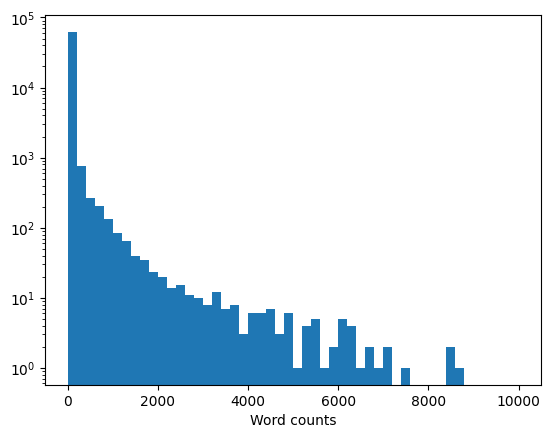

In [8]:
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts")
plt.show()

In [9]:
min_count = 10

tokens = sorted(t for t, c in token_counts.items() if c >= min_count)

UNK, PAD = "<UNK>", "<PAD>"
tokens = [UNK, PAD] + tokens

token_to_id = {token: id_ for id_, token in enumerate(tokens)}

print("Vocabulary size:", len(tokens))

Vocabulary size: 14837


In [10]:
for category_column in categorical_columns:
    print(f'Number of categories in column "{category_column}": {len(set([category for category in data[category_column]]))}')

Number of categories in column "billing_type": 4
Number of categories in column "response_letter_required": 2
Number of categories in column "area": 180
Number of categories in column "allow_messages": 2
Number of categories in column "experience": 4
Number of categories in column "schedule": 5
Number of categories in column "employment": 5
Number of categories in column "accept_handicapped": 2
Number of categories in column "accept_kids": 1
Number of categories in column "accept_incomplete_resumes": 2
Number of categories in column "employer": 8865
Number of categories in column "has_test": 2
Number of categories in column "accept_temporary": 2


In [11]:
from sklearn.feature_extraction import DictVectorizer
from collections import Counter

top_companies, top_counts = zip(*Counter(data['employer']).most_common(1000))
recognized_companies = set(top_companies)
data["employer"] = data["employer"].apply(lambda comp: comp if comp in recognized_companies else "Другая")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [39]:
import pickle

with open('../serialized/categorical_vectorizer.pkl', 'wb') as file:
    pickle.dump(categorical_vectorizer, file)

In [12]:
len(categorical_vectorizer.vocabulary_)

1206

## Creating dataset and dataloader

In [30]:
import torch
from torch.utils.data import Dataset, DataLoader, Sampler
from torch import nn

UNK_ID, PAD_ID = map(token_to_id.get, [UNK, PAD])

class JobsDataset(Dataset):
    def __init__(self, df):
        super().__init__()
        self.data = df
        self.data.index = np.arange(len(self.data))
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        return self.data.iloc[index]

We will use custom batch sampler for getting batch in collate_fn using `df.iloc[indices]` instead of `[df.iloc[i] for i in indices]`, in our case it will speed up data loading: https://github.com/pytorch/pytorch/issues/4959#issuecomment-362424598

In [31]:
class CustomBatchSampler(Sampler):
    def __init__(self, data_len, batch_size, shuffle=True):
        self.data_len = data_len
        self.batch_size = batch_size
        self.shuffle = shuffle

    def __len__(self):
        return (self.data_len + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        if self.shuffle:
            splits = np.array_split(np.random.permutation(self.data_len), len(self))
        else:
            splits = np.array_split(np.arange(self.data_len), len(self))
        splits = [[split.tolist()] for split in splits]
        return iter(splits)

In [32]:
MAX_SEQ_LEN = float('inf')


def get_tokens_batch(sequences):
    sequences = list(map(str.split, sequences))

    max_len = max(map(len, sequences))
    max_len = min(max_len, MAX_SEQ_LEN)
    
    tokens_batch = torch.full((len(sequences), max_len), PAD_ID)
    for i, seq in enumerate(sequences):
        row_ids = torch.tensor([token_to_id.get(word, UNK_ID) for word in seq[:max_len]], dtype=torch.int)
        tokens_batch[i, :len(row_ids)] = row_ids

    return tokens_batch


def collate_fn(batch):
    batch = batch[0]
    new_batch = {}
    new_batch['name'] = get_tokens_batch(batch['name'].values)
    new_batch['description'] = get_tokens_batch(batch['description'].values)
    new_batch['categorical'] = torch.from_numpy(categorical_vectorizer.transform(batch[categorical_columns].apply(dict, axis=1)))
    
    if TARGET_COLUMN in data.columns:
        new_batch[TARGET_COLUMN] = torch.from_numpy(batch[TARGET_COLUMN].values)
    
    return new_batch

In [33]:
from sklearn.model_selection import train_test_split

BATCH_SIZE = 32

def create_loaders(data, test_size = 0.2, random_state = 42, batch_size = BATCH_SIZE, collate_fn = collate_fn, num_workers = 4):
    train_df, val_df = train_test_split(data, test_size=test_size, random_state=random_state)

    train_data = JobsDataset(train_df)
    val_data = JobsDataset(val_df)

    train_batch_sampler = CustomBatchSampler(data_len=len(train_data), batch_size=batch_size, shuffle=True)
    val_batch_sampler = CustomBatchSampler(data_len=len(val_data), batch_size=batch_size, shuffle=False)

    train_loader = DataLoader(train_data, batch_sampler=train_batch_sampler, collate_fn=collate_fn, num_workers=num_workers)
    val_loader = DataLoader(val_data, batch_sampler=val_batch_sampler, collate_fn=collate_fn, num_workers=num_workers)

    print("Train size = ", len(train_data))
    print("Validation size = ", len(val_data))

    return train_loader, val_loader

train_loader, val_loader = create_loaders(data)

Train size =  17829
Validation size =  4458


## Defining model (LSTM + 1d convolution + GloVe embeddings)

In [18]:
from tqdm.auto import tqdm

def load_glove_weights(file_path, vocab, pad_token='<PAD>'):
    print('Loading Glove Weights')
    glove_weights = np.random.normal(0, 1, (len(vocab), 300))
    mask_found = np.zeros(len(vocab), dtype=bool)
    
    with open(file_path, 'r') as f:
        for line in tqdm(f, total=63068):
            line = line.split()
            token = ' '.join(line[:-300])
            embed = line[-300:]

            if token in vocab:
                ind = vocab[token]
                mask_found[ind] = True
                glove_weights[ind, :] = np.array(list(map(float, embed)), dtype=np.float64)

    print(f'{mask_found.sum()} words from vocab of size {len(vocab)} loaded!')

    glove_weights[vocab[pad_token]] = np.zeros(300, dtype=np.float64)
    return glove_weights, mask_found


glove_path = '../data/multilingual_embeddings.ru'
glove_weights, mask_found = load_glove_weights(glove_path, token_to_id, '<PAD>')
glove_weights[:2]

  0%|          | 0/63068 [00:00<?, ?it/s]

Loading Glove Weights


100%|██████████| 63068/63068 [00:01<00:00, 44859.69it/s]

8714 words from vocab of size 14837 loaded!


array([[-1.75482455e+00,  1.89188445e-01, -8.88322879e-02,
        -7.79880464e-01,  1.29877622e+00, -9.60341387e-01,
         8.13313647e-01,  7.80158082e-02, -1.15342594e-02,
        -1.01016709e+00,  5.23653401e-01, -6.54250943e-01,
        -1.40304618e+00, -4.95117587e-01,  5.06565756e-01,
         4.66116633e-02, -7.31368121e-01,  9.02957345e-01,
         5.84820174e-01, -1.40764025e+00, -1.55144014e+00,
         5.74557751e-01, -2.76829233e-01,  1.81218411e+00,
        -5.52966387e-01, -3.91691109e-01, -3.83715025e-01,
        -1.98973633e-01, -1.02751041e-01,  1.82543885e-01,
        -8.32774885e-02, -1.45440922e+00,  5.82116237e-02,
        -5.26367901e-01, -1.79018512e+00,  6.74612836e-01,
        -8.65530051e-02,  1.62130424e+00,  1.06165477e+00,
        -6.24450002e-01, -6.47714690e-01,  7.06478569e-01,
         6.14865252e-01,  3.61740604e-01,  9.12171217e-01,
         9.01721690e-01,  8.50598773e-01, -2.96701386e-01,
        -3.50144043e-01, -1.24785089e+00,  5.70164893e-0

We will use model with convolutional title encoder, LSTM description encoder and full-connected layer for categorical features. Model concatenates outputs of these encoders into one features vector and uses this vector as input in final full-connected output layer.

In [19]:
class ConvLSTMSalaryPredictor(nn.Module):
    def __init__(self, token_weights=np.zeros((len(token_to_id), 300)), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=100):
        super().__init__()
        n_tokens = token_weights.shape[0]
        n_token_features = token_weights.shape[1]
        self.emb = nn.Embedding(num_embeddings=n_tokens, embedding_dim=n_token_features)
        self.emb.weight = nn.Parameter(
                torch.from_numpy(token_weights).to(torch.float),
                requires_grad = True,
            )
        self.conv_title = nn.Sequential(
            nn.ConstantPad1d((3, 0), 0),
            nn.Conv1d(n_token_features, hid_size, 3),
            nn.BatchNorm1d(hid_size),
            nn.ReLU()
        )
        self.lstm_descr = nn.LSTM(
            input_size=n_token_features,
            hidden_size=hid_size,
            num_layers=3,
            bidirectional=True,
            batch_first=True,
        )
        self.cat_linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.ReLU()
        )
        self.fc = nn.Sequential(
            nn.Linear(4 * hid_size, hid_size),
            nn.BatchNorm1d(hid_size),
            nn.ReLU(),
            nn.Linear(hid_size, 1),
        )
        
    def forward(self, batch):
        device = self.emb.weight.device
    
        title = batch['name'].to(device)
        full_description = batch['description'].to(device)
        categorical = batch['categorical'].to(device)
        
        title_emb = self.emb(title).transpose(1, 2)
        title_conv = self.conv_title(title_emb)
        title_features, _ = torch.max(title_conv, axis=2)

        descr_emb = self.emb(full_description)
        lstm_descr_output, (hn, cn) = self.lstm_descr(descr_emb)
        descr_features = lstm_descr_output.mean(1)

        cat_features = self.cat_linear(categorical)
        all_features = torch.concatenate([title_features, descr_features, cat_features], axis=1)
        result = self.fc(all_features).squeeze(1)
        return result

In [20]:
def get_parameters_number(model):
    print(f'Number of trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}')
    print(f'Number of all parameters: {sum(p.numel() for p in model.parameters())}')

In [21]:
get_parameters_number(ConvLSTMSalaryPredictor())

Number of trainable parameters: 5507301
Number of all parameters: 5507301


## Model training

In [19]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [20]:
import torch.nn.functional as F
from tqdm.auto import tqdm
from IPython.display import clear_output


def train(model, optimizer, train_loader, criterion, device=device):
    model.train()
    losses = []
    for batch in tqdm(train_loader):
        pred = model(batch)

        loss = criterion(pred, batch[TARGET_COLUMN].to(device))
        losses.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return np.mean(losses)

def val(model, val_loader, device=device):
    model.eval()
    
    mse_losses = []
    mae_losses = []

    with torch.no_grad():
        for batch in tqdm(val_loader):
            pred = model(batch)
            target = batch[TARGET_COLUMN].to(device)
            
            mse_loss = F.mse_loss(pred, target)
            mae_loss = F.l1_loss(pred, target)
            
            mse_losses.append(mse_loss.item())
            mae_losses.append(mae_loss.item())
    
    return np.mean(mse_losses), np.mean(mae_losses)

def train_loop(model, optimizer, criterion, train_loader, val_loader, num_epochs):
    train_losses, val_mse_losses, val_mae_losses = [], [], []
    
    for epoch in range(1, num_epochs + 1):
        print(f"epoch: {epoch}")
        train_loss = train(model, optimizer, train_loader, criterion, device=device)
        train_losses.append(train_loss)

        val_mse_loss, val_mae_loss = val(model, val_loader, device=device)
        val_mse_losses.append(val_mse_loss)
        val_mae_losses.append(val_mae_loss)

        clear_output(True)
        fig, ax = plt.subplots(1, 2, figsize=(20, 10))
        fig.suptitle(f'#{epoch}/{num_epochs}:')

        plt.subplot(1, 2, 1)
        plt.title('Train MSE loss')
        plt.plot(train_losses)
        plt.legend()
        plt.grid()

        plt.subplot(1, 2, 2)
        plt.title('Validation losses')
        plt.plot(val_mse_losses, 'r.-', label='MSE')    
        plt.plot(val_mae_losses, 'g.-', label='MAE')
        plt.legend()
        plt.grid()

        plt.show()

        print(f'train MSE losses: {train_losses}' if len(train_losses) < 5 else f'Last 5 train MSE losses: {train_losses[-5:]}')
        print(f'validation MSE losses: {val_mse_losses}' if len(val_mse_losses) < 5 else f'Last 5 validation MSE losses: {val_mse_losses[-5:]}')
        print(f'validation MAE losses: {val_mae_losses}' if len(val_mae_losses) < 5 else f'Last 5 validation MAE losses: {val_mae_losses[-5:]}')
    
    return train_losses, val_mse_losses, val_mae_losses

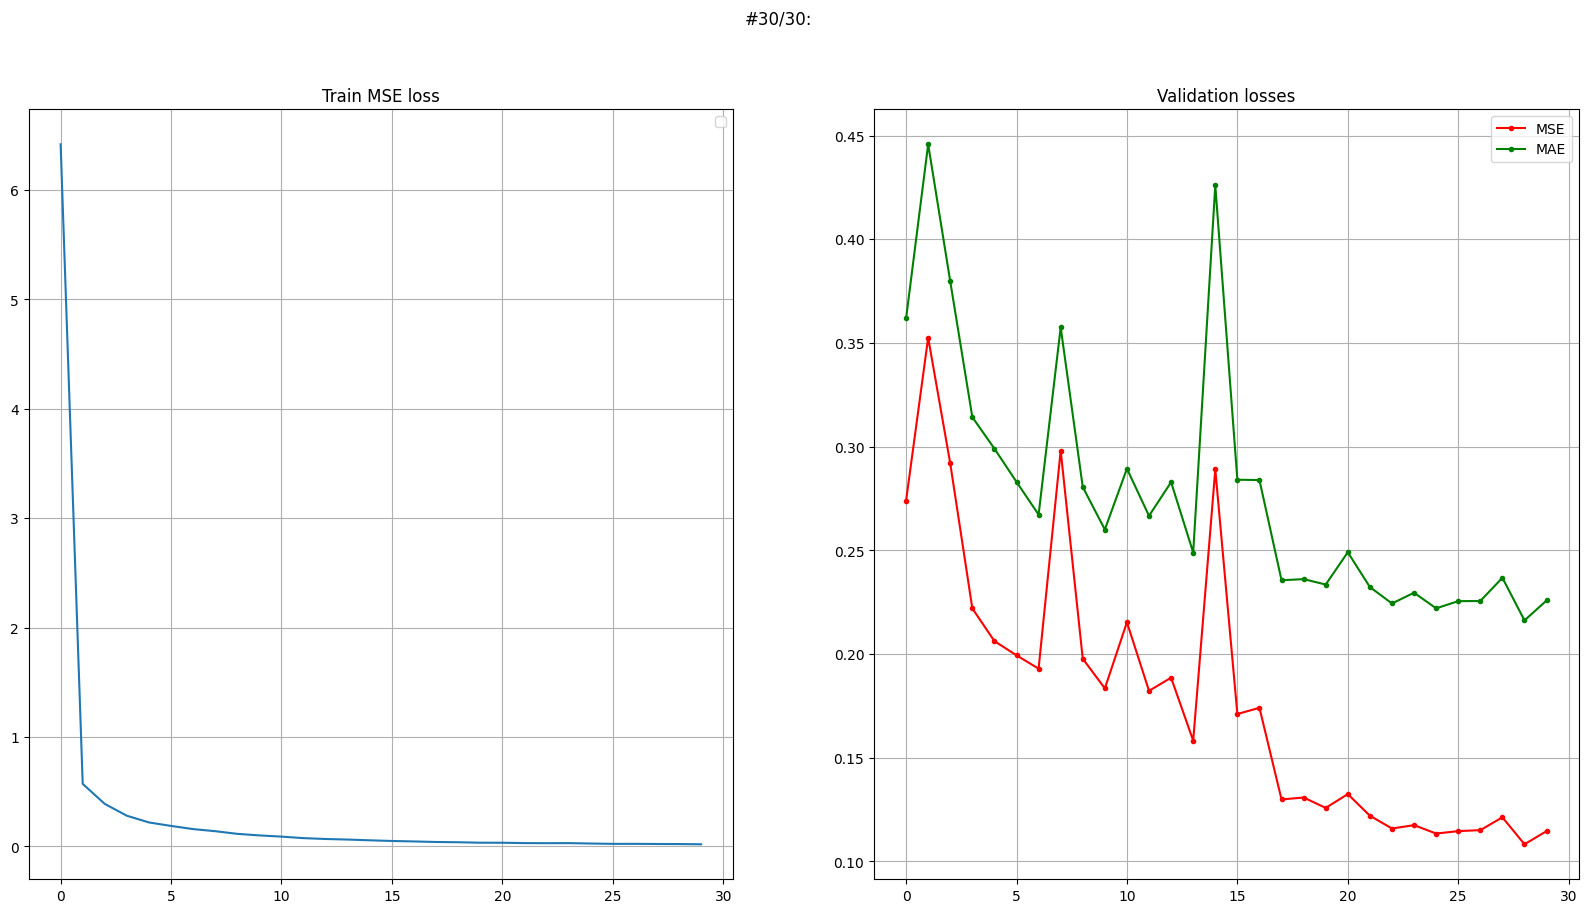

Last 5 train MSE losses: [0.024126399218315078, 0.02429836437750381, 0.023019586009637695, 0.022233410498067256, 0.020305984852147893]
Last 5 validation MSE losses: [0.1146096191102905, 0.115081058735294, 0.12126762576933418, 0.10826920006158096, 0.11462357315633978]
Last 5 validation MAE losses: [0.22549332731536456, 0.22556424939206668, 0.236762064908232, 0.21619720480271748, 0.22581367939710617]


In [134]:
EPOCHS = 30
criterion = nn.MSELoss()
conv_lstm_model = ConvLSTMSalaryPredictor().to(device)
optimizer = torch.optim.Adam(conv_lstm_model.parameters(), lr=1e-3)

conv_lstm_train_losses, conv_lstm_val_mse_losses, conv_lstm_val_mae_losses = train_loop(conv_lstm_model, optimizer, criterion, train_loader, val_loader, num_epochs=EPOCHS)

In [38]:
SP_WEIGHTS_PATH = '../weights/salary_prediction_models'

torch.save(conv_lstm_model.state_dict(), f'{SP_WEIGHTS_PATH}/convlstmglove.weights')

## Defining model (BERT)

Now we will train BERT, for this we should build another dataloader, because BERT uses another tokenizer. Also we will merge title and description columns, because for processing text data we want to use only BERT, and it will be expensive to use 2 BERT models for title and description separately.

### rubert-tiny2

In [23]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'cointegrated/rubert-tiny2'
rubert_tiny2_tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = 100
rubert_tiny2_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

/home/jupyter/.local/lib/python3.10/site-packages/transformers/utils/hub.py:123: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
tokenizer_config.json: 100%|██████████| 401/401 [00:00<00:00, 3.05MB/s]
vocab.txt: 100%|██████████| 1.08M/1.08M [00:00<00:00, 7.96MB/s]
tokenizer.json: 100%|██████████| 1.74M/1.74M [00:00<00:00, 14.0MB/s]
config.json: 100%|██████████| 693/693 [00:00<00:00, 5.53MB/s]
model.safetensors: 100%|██████████| 118M/118M [00:01<00:00, 102MB/s]  
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
get_parameters_number(rubert_tiny2_model)

Number of trainable parameters: 29225068
Number of all parameters: 29225068


In [25]:
def collate_fn_with_tokenizer(batch, tokenizer):
    batch = batch[0]
    new_batch = {}
    new_batch['name_and_description'] = tokenizer(batch['name_and_description'].values.tolist(), padding=True, truncation=True, max_length=512, return_tensors="pt")
    new_batch['categorical'] = torch.from_numpy(categorical_vectorizer.transform(batch[categorical_columns].apply(dict, axis=1)))
    
    if TARGET_COLUMN in data.columns:
        new_batch[TARGET_COLUMN] = torch.from_numpy(batch[TARGET_COLUMN].values)
    
    return new_batch

def get_collate_fn_with_tokenizer(tokenizer):
    return (lambda batch: collate_fn_with_tokenizer(batch=batch, tokenizer=tokenizer))

In [26]:
train_loader, val_loader = create_loaders(data, collate_fn=get_collate_fn_with_tokenizer(rubert_tiny2_tokenizer))

Train size =  17829
Validation size =  4458


In [42]:
class BERTSalaryPredictor(nn.Module):
    def __init__(self,  bert, hid_size, n_cat_features=len(categorical_vectorizer.vocabulary_)):
        super().__init__()
        self.bert = bert
        self.fc = nn.Sequential(
            nn.Linear(2 * hid_size, hid_size),
            nn.ReLU(),
            nn.Linear(hid_size, 1)
        )
        self.cat_linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.ReLU()
        )
        
    def forward(self, batch):
        device = self.bert.device
    
        title_and_description = batch['name_and_description'].to(device)
        categorical = batch['categorical'].to(device)

        title_and_desrc_features = self.bert(**title_and_description).logits
        cat_features = self.cat_linear(categorical)
        
        all_features = torch.concatenate([title_and_desrc_features, cat_features], axis=1)
        result = self.fc(all_features).squeeze(1)
        return result

In [29]:
get_parameters_number(BERTSalaryPredictor(bert=rubert_tiny2_model, hid_size=num_labels))

Number of trainable parameters: 29365969
Number of all parameters: 29365969


In [30]:
import os

os.environ["TOKENIZERS_PARALLELISM"] = "false"

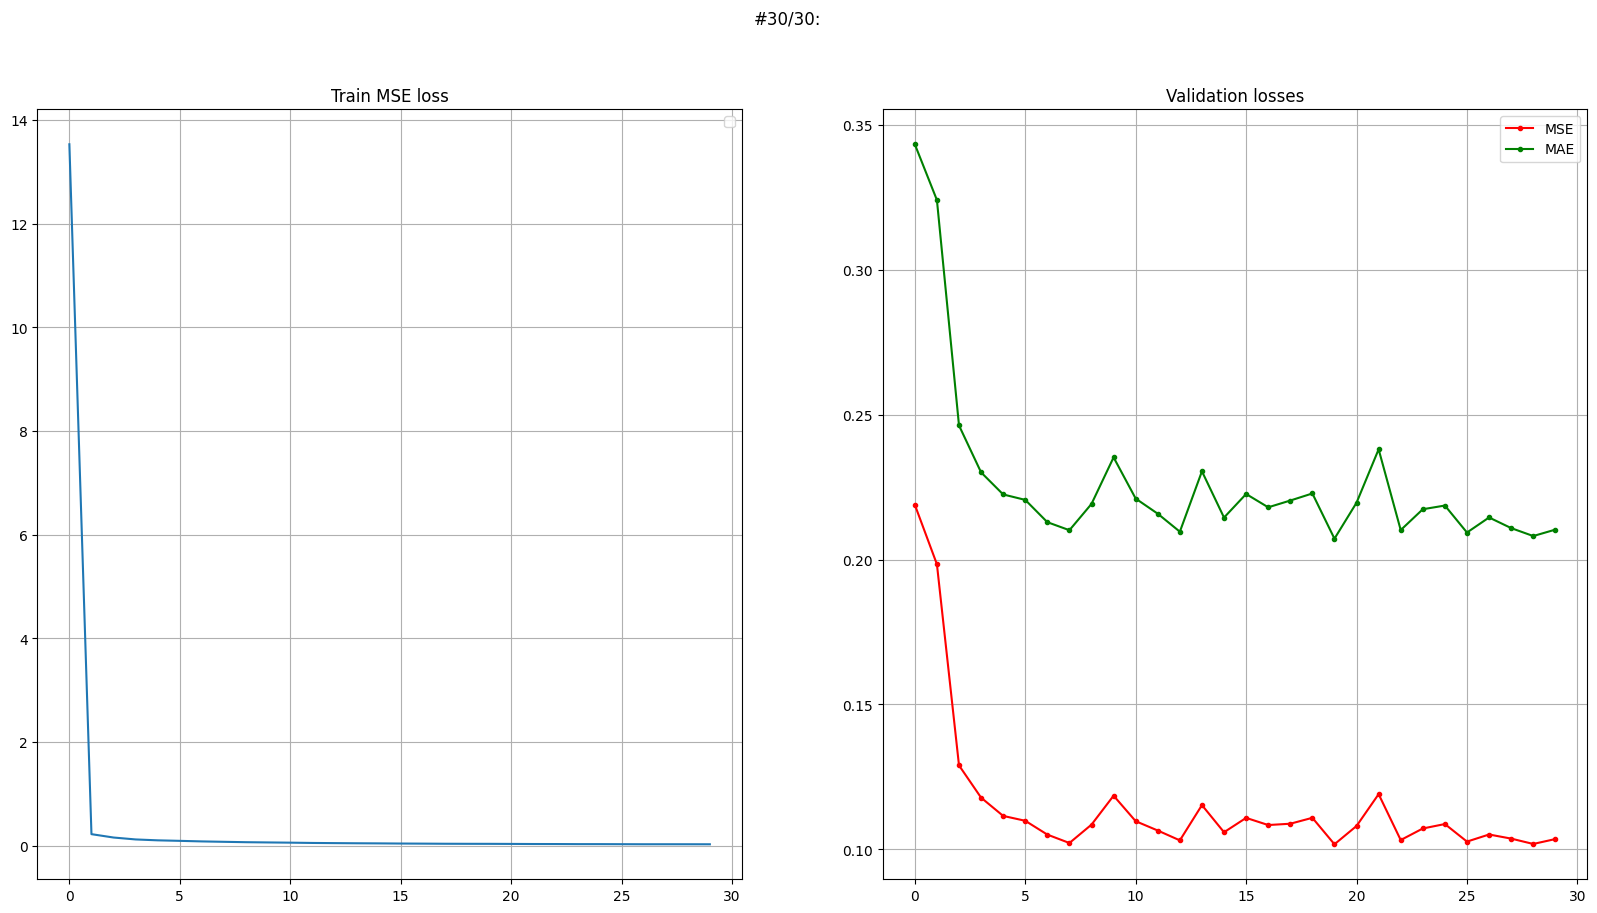

Last 5 train MSE losses: [0.0308834350447581, 0.029702408684878258, 0.02995089320031973, 0.02970338689737476, 0.029253746259383404]
Last 5 validation MSE losses: [0.10267247596223439, 0.10512356643698045, 0.10370940798893571, 0.10185872585113559, 0.10354899001706924]
Last 5 validation MAE losses: [0.20934920289686748, 0.2145506990807397, 0.21088337302207946, 0.20814143983381136, 0.21035434465323175]


In [171]:
EPOCHS = 30
criterion = nn.MSELoss()
rubert_tiny2_sp = BERTSalaryPredictor(bert=rubert_tiny2_model, hid_size=num_labels).to(device)
optimizer = torch.optim.Adam(rubert_tiny2_sp.parameters(), lr=2e-5)

bert_tiny_train_losses, bert_tiny_val_mse_losses, bert_tiny_val_mae_losses = train_loop(rubert_tiny2_sp, optimizer, criterion, train_loader, val_loader, num_epochs=EPOCHS)

In [37]:
torch.save(rubert_tiny2_sp.state_dict(), f'{SP_WEIGHTS_PATH}/rubert_tiny2.weights')

### rubert-tiny

In [42]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'cointegrated/rubert-tiny'
rubert_tiny_tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = 100
rubert_tiny_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [43]:
get_parameters_number(rubert_tiny_model)

Number of trainable parameters: 11815468
Number of all parameters: 11815468


In [35]:
train_loader, val_loader = create_loaders(data, collate_fn=get_collate_fn_with_tokenizer(rubert_tiny_tokenizer))

Train size =  17829
Validation size =  4458


In [45]:
get_parameters_number(BERTSalaryPredictor(bert=rubert_tiny_model, hid_size=num_labels))

Number of trainable parameters: 11956369
Number of all parameters: 11956369


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


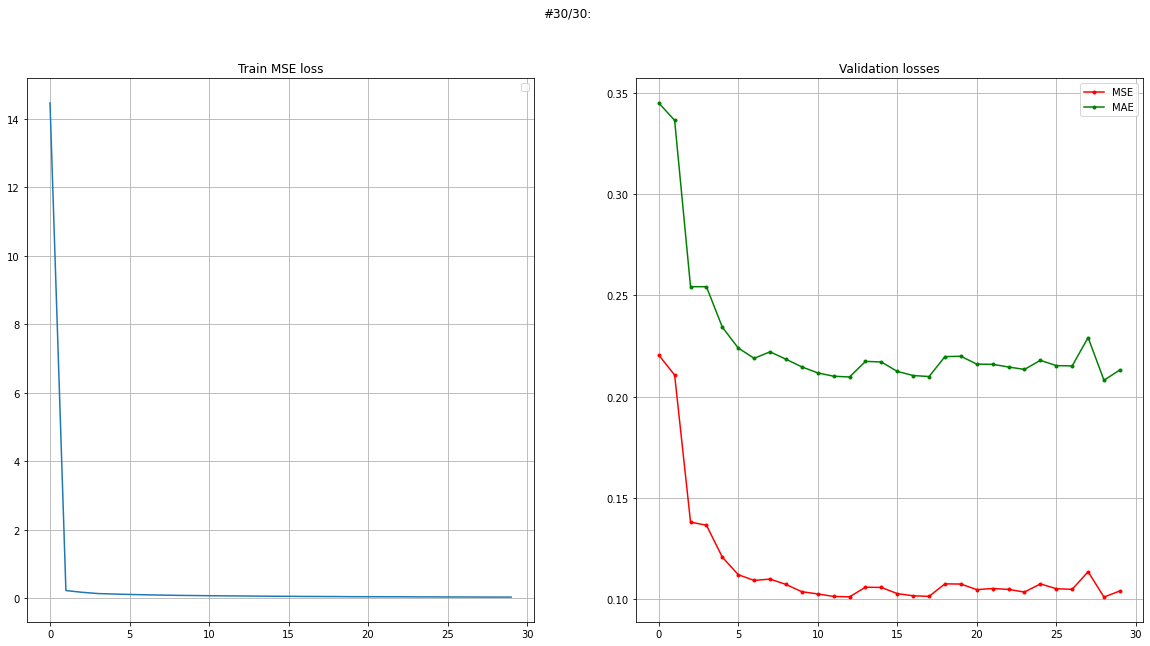

Last 5 train MSE losses: [0.04016439835157072, 0.04002485351176352, 0.03813867540662861, 0.03687266006191198, 0.03707976829207178]
Last 5 validation MSE losses: [0.10527731323880808, 0.10496564869369779, 0.11367302443832158, 0.10114202333082045, 0.10419087891599961]
Last 5 validation MAE losses: [0.21531671551721437, 0.21517074991549764, 0.2291641913354397, 0.20810525502477373, 0.21319068425468035]


In [46]:
EPOCHS = 30
criterion = nn.MSELoss()
rubert_tiny_sp = BERTSalaryPredictor(bert=rubert_tiny_model, hid_size=num_labels).to(device)
optimizer = torch.optim.Adam(rubert_tiny_sp.parameters(), lr=2e-5)

bert_tiny_train_losses, bert_tiny_val_mse_losses, bert_tiny_val_mae_losses = train_loop(rubert_tiny_sp, optimizer, criterion, train_loader, val_loader, num_epochs=EPOCHS)

In [47]:
torch.save(rubert_tiny_sp.state_dict(), f'{SP_WEIGHTS_PATH}/rubert_tiny.weights')

### rubert-base-cased

In [44]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_name = 'DeepPavlov/rubert-base-cased'
rubert_base_cased_tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = 512
rubert_base_cased_model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to(device)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at DeepPavlov/rubert-base-cased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [46]:
train_loader, val_loader = create_loaders(data, collate_fn=get_collate_fn_with_tokenizer(rubert_base_cased_tokenizer))

Train size =  17829
Validation size =  4458


In [47]:
get_parameters_number(BERTSalaryPredictor(bert=rubert_base_cased_model))

Number of trainable parameters: 179390465
Number of all parameters: 179390465


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


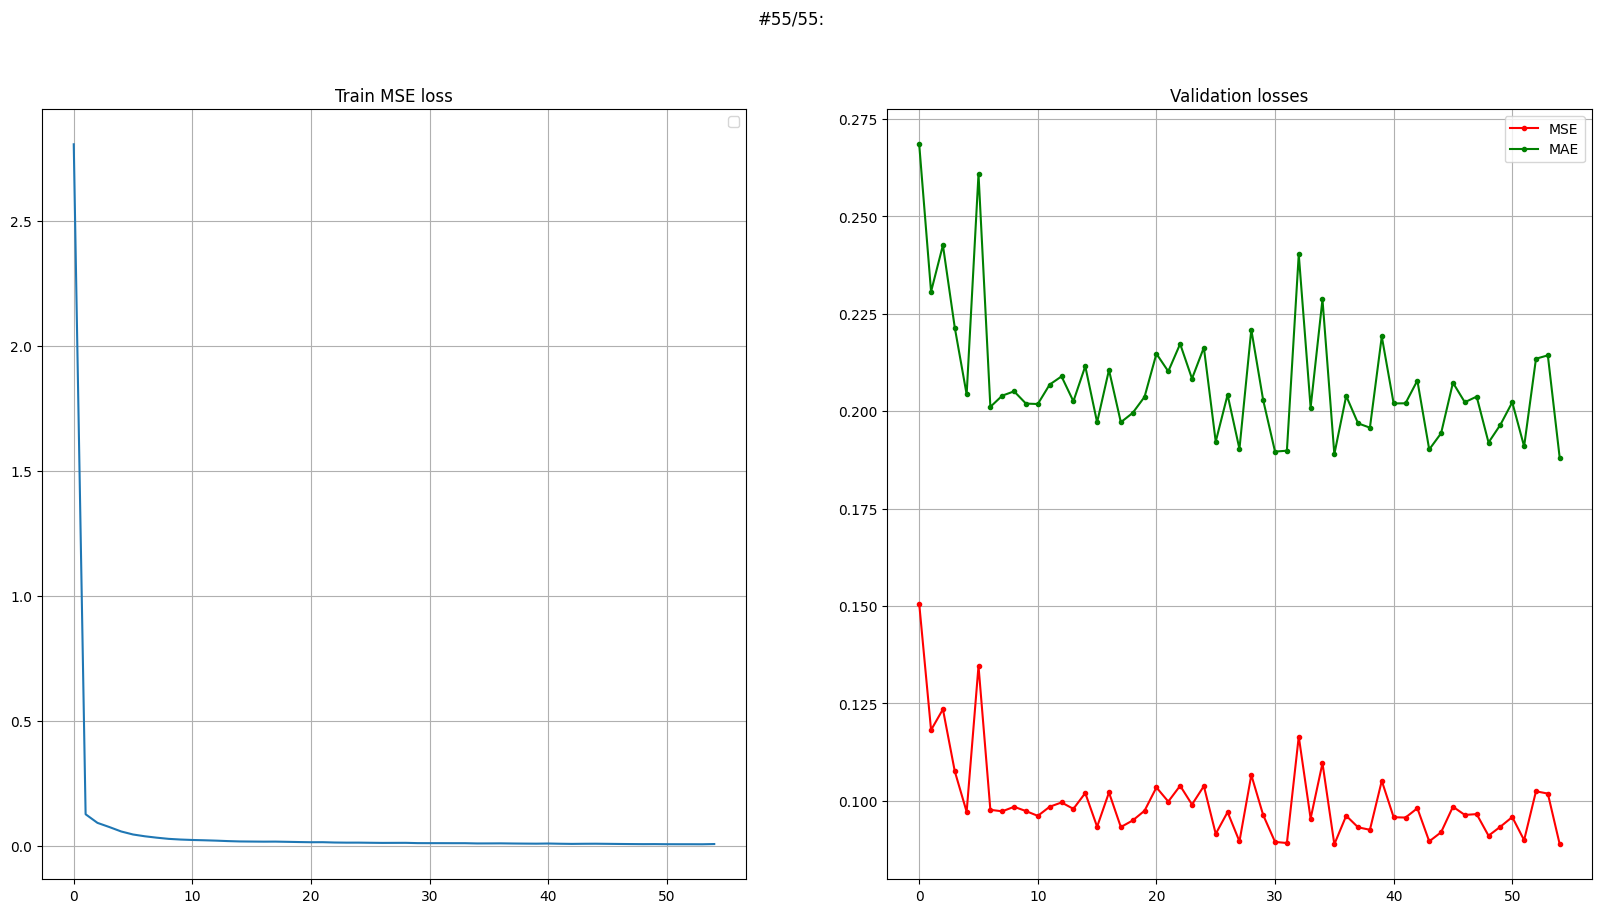

In [56]:
EPOCHS = 55
criterion = nn.MSELoss()
rubert_base_cased_sp = BERTSalaryPredictor(bert=rubert_base_cased_model, hid_size=num_labels).to(device)
optimizer = torch.optim.Adam(rubert_base_cased_sp.parameters(), lr=2e-5)

bert_tiny_train_losses, bert_tiny_val_mse_losses, bert_tiny_val_mae_losses = train_loop(rubert_base_cased_sp, optimizer, criterion, train_loader, val_loader, num_epochs=EPOCHS)

In [36]:
torch.save(rubert_base_cased_sp.state_dict(), f'{SP_WEIGHTS_PATH}/rubert_base_cased.weights')